In [98]:
import numpy as np
import matplotlib.pyplot as plt

Pretpostavimo da gustina gasa opada od fotosfere na gore eksponencijalno, gde je skala visine npr. 5000 km. Pretpostavi da je centralni deo zvezde slican Suncu, tj ima poluprecnik 700 000 km. Pretpostavi da je gustina vodonika na povrsini npr 10E21 cestica po cm^3. 


In [99]:
H = 5000 * 1e5  # cm
n0 = 10e21 # cm^-3
R = 700000 * 1e5  # cm

In [100]:
def n(r):
    return n0 * np.exp(-(r-R)/H)

1) Za pravce vizure koji su paralelni sa pravcem centar zvezde - posmatrac i ne seku centralni deo zvezde (tj. nalaze se u omotaču), izračunaj broj atoma po jedinici površine duž pravca vizure (tzv. površinsku gustinu atoma duž pravca vizure). 

Isplotuj ova rezultat kao n (r) gde je r udaljenost datog zraka od pravca centar zvezde - posmatrač. 

In [101]:
z = np.linspace(-5*R, R*5, 1000) # koordinata duz pravca vizure
r_values = np.linspace(R, R + 10*H, 1000) # udaljenost od centra  

In [102]:
N= []

for r in r_values:
    r_rad = np.sqrt(z**2 + r**2)
    n_r = n(r_rad)
    n_r[r_rad < R] = 0  # Postavi gustinu na nulu unutar zvezde
  
    integral = np.trapezoid(n_r, z)  # Integracija duž pravca vizure 

    N.append(integral)

N = np.array(N)

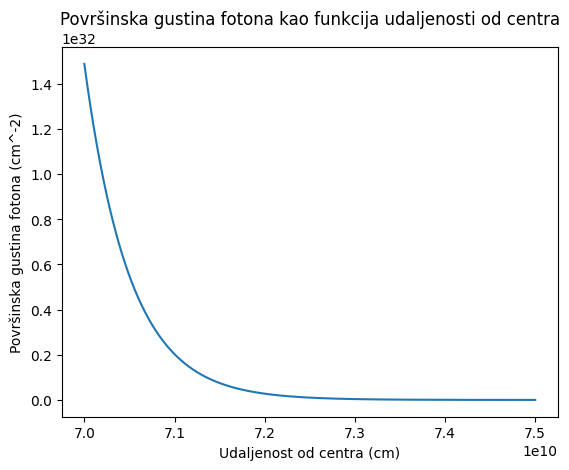

In [103]:
plt.plot(r_values, N)
plt.xlabel('Udaljenost od centra (cm)')
plt.ylabel('Površinska gustina fotona (cm^-2)') 
plt.title('Površinska gustina fotona kao funkcija udaljenosti od centra')
plt.show()  

2) Pretpostavi da se neprozračnost u centru Halpha linije vodonika može napisati kao broj atoma vodonika pa puta neka konstanta (ova konstanta će u sebi apsorbovati i Bolcmanovu raspodelu itd, nećemo sada da se time zamaramo). Namesti da ti da konstanta bude takva da optička dubina u centru Halpha linije za zrak r=R bude npr. 1000. 

Da to uradiš, seti se da je optička dubina jednaka integralu neprozračnosti puta put, a neprozračnost smo definisali gore. Treba da dobiješ da je optička dubina jednaka ono n koje si našla u delu 1) puta ova novo definisana konstanta. 

Ovo sve je pretpostavljajući da nema doplerovog pomaka! (To ostavljamo za sledeći domaći). 

Isplotuj sada optičku dubinu duž pravca vizure u zavisnosti od r. 

In [104]:
const = 1000/N[0]
tau = const * N

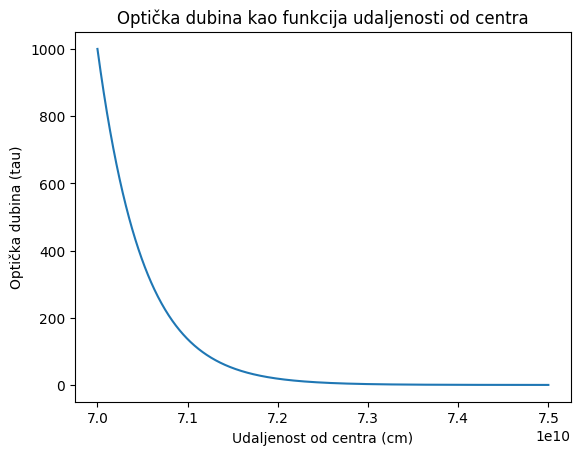

In [105]:
plt.plot(r_values, tau)
plt.xlabel('Udaljenost od centra (cm)')
plt.ylabel('Optička dubina (tau)')
plt.title('Optička dubina kao funkcija udaljenosti od centra')
plt.show()

3) Sada ćemo da rešavamo JPZ. Pretpostavi da je funkcija izvora svuda u omotaču ista. Reši jednačinu prenosa za ovaj slučaj. Treba da dobiješ da je inenzitet jednak S(1-e^-tau). 

Isplotuj sada intenzitet u zavisnosti od r. 

Pokušaj da se ubediš da r na kom intenzitet pada na neku zanemarljivu vrednost (npr I = 0.01 I(R)), definiše veličinu vidljive zvezdane atmosfere. 

Ispitaj kako odabir skale visine utiče na veličinu zvezde, a i kako odabir one konstante koja odredjuje neprozračnost utiče na veličinu zvezde. 

In [106]:
S = 1 # neka konstanta
I = S * (1- np.exp(-tau))

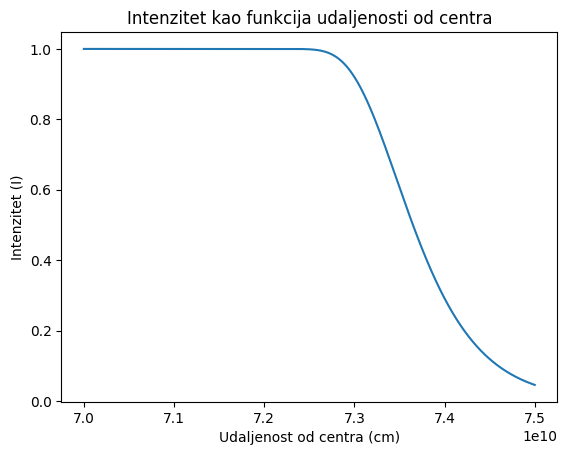

In [107]:
plt.plot(r_values, I)
plt.xlabel('Udaljenost od centra (cm)')
plt.ylabel('Intenzitet (I)')            
plt.title('Intenzitet kao funkcija udaljenosti od centra')
plt.show()
